In [1]:
print("jupyter is working")

jupyter is working


In [2]:
import pandas as pd

df = pd.read_csv("iris.csv")

df.head()

,150,4,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
print(df.columns.tolist())

['150', '4', 'setosa', 'versicolor', 'virginica']


In [6]:
print(df.dtypes)

150           float64
4             float64
setosa        float64
versicolor    float64
virginica       int64
dtype: object


In [7]:
print(df.isnull().sum())

150           0
4             0
setosa        0
versicolor    0
virginica     0
dtype: int64


In [8]:
df = pd.read_csv("iris.csv", header=None)

df.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "target"
]

df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,150.0,4.0,setosa,versicolor,virginica
1,5.1,3.5,1.4,0.2,0
2,4.9,3.0,1.4,0.2,0
3,4.7,3.2,1.3,0.2,0
4,4.6,3.1,1.5,0.2,0


In [9]:
df = pd.read_csv("iris.csv", skiprows=1, header=None)

df.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "target"
]

df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
print(df.shape)

(150, 5)


In [11]:
print(df.dtypes)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
target            int64
dtype: object


In [12]:
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
dtype: int64


In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [15]:
df = df.drop_duplicates()

In [16]:
print("Duplicate rows:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicate rows: 0
New shape: (149, 5)


In [17]:
numeric_cols = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(col, "→ Outliers:", len(outliers))

sepal_length → Outliers: 0
sepal_width → Outliers: 4
petal_length → Outliers: 0
petal_width → Outliers: 0


In [18]:
Q1 = df["sepal_width"].quantile(0.25)
Q3 = df["sepal_width"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["sepal_width"] >= lower) & (df["sepal_width"] <= upper)]

print("New shape:", df.shape)

New shape: (145, 5)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,-0.907877,1.152206,-1.366548,-1.341462,0
1,-1.147662,-0.107748,-1.366548,-1.341462,0
2,-1.387447,0.396234,-1.423536,-1.341462,0
3,-1.507340,0.144243,-1.309559,-1.341462,0
4,-1.027769,1.404196,-1.366548,-1.341462,0


In [20]:
print(df[numeric_cols].mean())

sepal_length    7.840472e-16
sepal_width    -3.430206e-16
petal_length   -1.960118e-16
petal_width    -9.800589e-17
dtype: float64


In [21]:
print(df.describe())

       sepal_length   sepal_width  petal_length   petal_width      target
count  1.450000e+02  1.450000e+02  1.450000e+02  1.450000e+02  145.000000
mean   7.840472e-16 -3.430206e-16 -1.960118e-16 -9.800589e-17    1.013793
std    1.003466e+00  1.003466e+00  1.003466e+00  1.003466e+00    0.816379
min   -1.867017e+00 -2.123673e+00 -1.594502e+00 -1.473514e+00    0.000000
25%   -9.078765e-01 -6.117291e-01 -1.252571e+00 -1.209411e+00    0.000000
50%   -6.862819e-02 -1.077477e-01  3.431108e-01  1.111055e-01    1.000000
75%    6.507275e-01  6.482243e-01  7.420312e-01  7.713635e-01    2.000000
max    2.449117e+00  2.412159e+00  1.767826e+00  1.695725e+00    2.000000


In [22]:
df.to_csv("iris_final.csv", index=False)

print("Final dataset saved successfully")
print("Final shape:", df.shape)

Final dataset saved successfully
Final shape: (145, 5)


In [23]:
print("Final dataset preview:")
print(df.head())

Final dataset preview:
   sepal_length  sepal_width  petal_length  petal_width  target
0     -0.907877     1.152206     -1.366548    -1.341462       0
1     -1.147662    -0.107748     -1.366548    -1.341462       0
2     -1.387447     0.396234     -1.423536    -1.341462       0
3     -1.507340     0.144243     -1.309559    -1.341462       0
4     -1.027769     1.404196     -1.366548    -1.341462       0


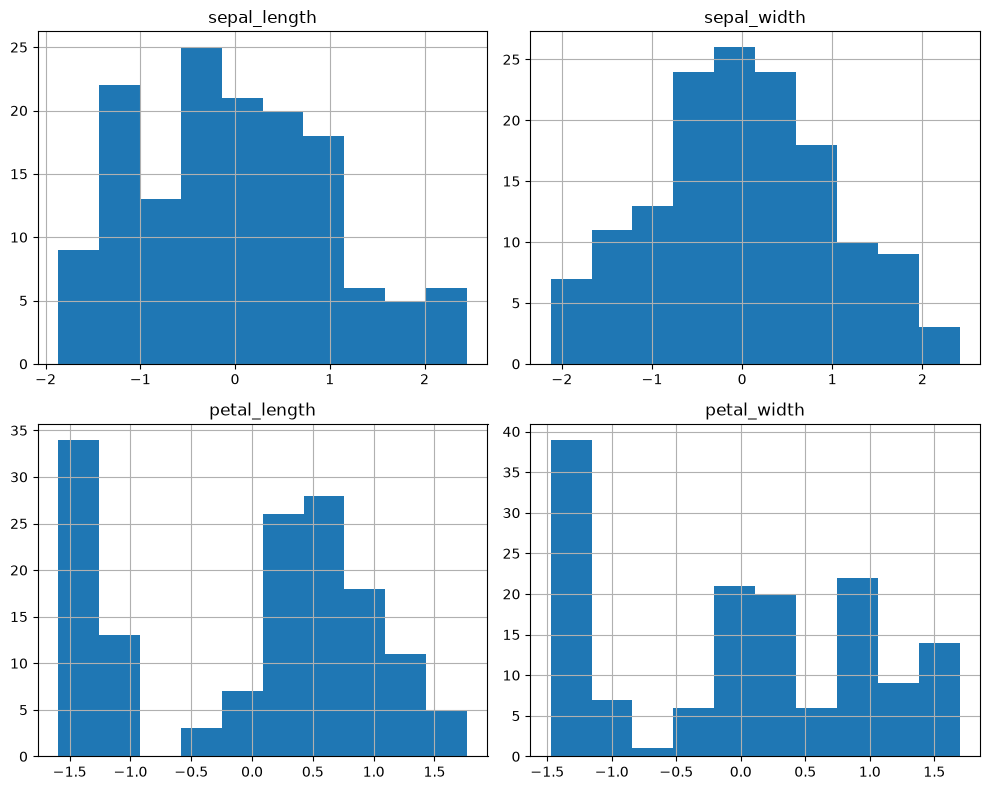

In [24]:
import matplotlib.pyplot as plt

df[numeric_cols].hist(figsize=(10, 8))

plt.tight_layout()
plt.show()

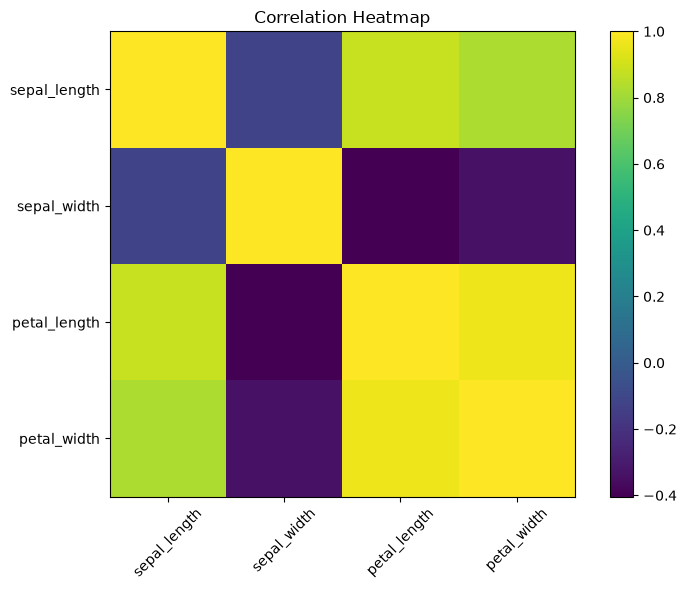

In [25]:
import matplotlib.pyplot as plt

correlation = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation)
plt.colorbar()

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

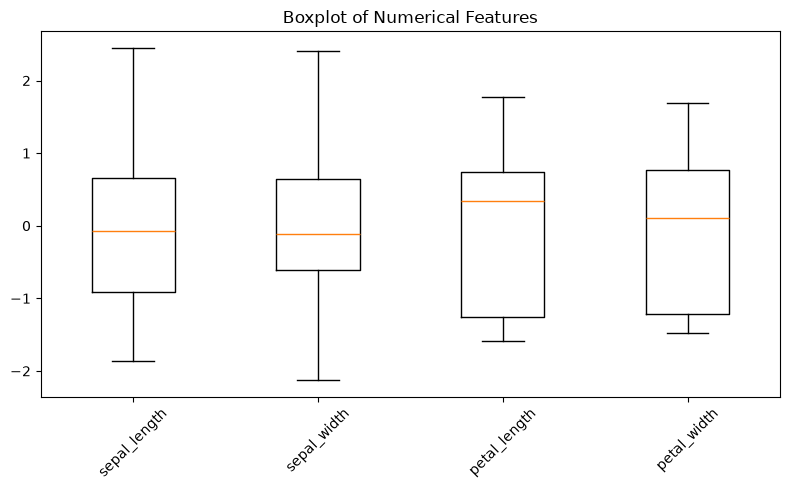

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(
    df[numeric_cols].values,
    tick_labels=numeric_cols
)

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Check correlation between numerical features

correlation = df[numeric_cols].corr()

print(correlation)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.123866      0.881381     0.825321
sepal_width      -0.123866     1.000000     -0.403554    -0.337080
petal_length      0.881381    -0.403554      1.000000     0.961776
petal_width       0.825321    -0.337080      0.961776     1.000000


In [29]:
# Check target distribution

print("Target value counts:")
print(df["target"].value_counts())

Target value counts:
target
1    49
2    49
0    47
Name: count, dtype: int64


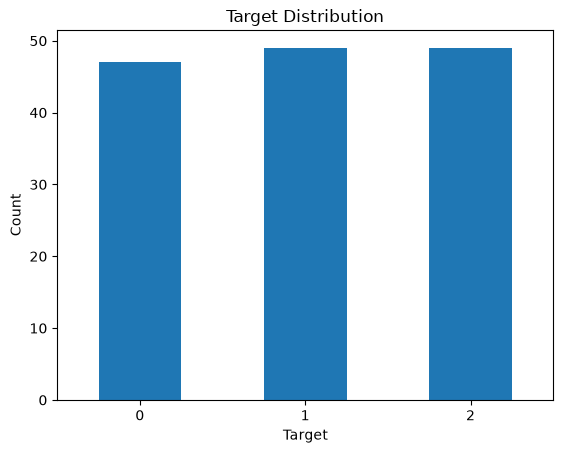

In [30]:
import matplotlib.pyplot as plt

df["target"].value_counts().sort_index().plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

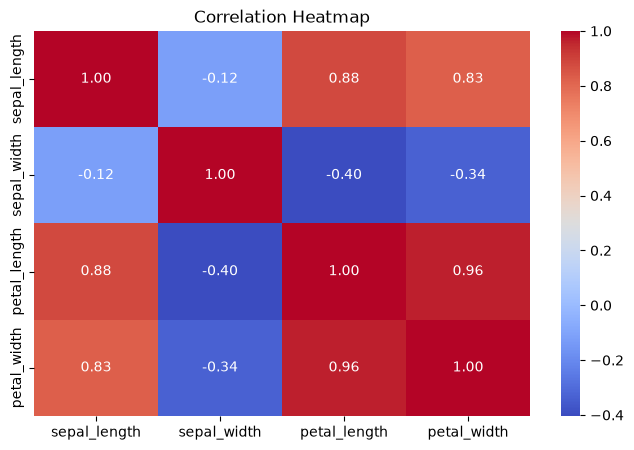

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [32]:
print("Final dataset shape:", df.shape)
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Final dataset shape: (145, 5)
Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
dtype: int64

Duplicate rows: 0


In [33]:
import os

print("File exists:", os.path.exists("iris_final.csv"))

if os.path.exists("iris_final.csv"):
    print("File size:", os.path.getsize("iris_final.csv"), "bytes")

File exists: True
File size: 11815 bytes
